# Mortgage & Structured Finance Risk Modelling – Results & Analysis

## Objective
This notebook implements an end-to-end mortgage and structured finance risk-modelling workflow in Python.  
The objective is to simulate **loan-level mortgage cashflows**, aggregate them into a **mortgage pool**, analyse **prepayment and credit risk**, and evaluate **interest-rate sensitivity** through scenario analysis.

The modelling approach prioritises **economic intuition, transparency, and interpretability**, reflecting how mortgage risk analytics are used in practice for Whole Loans, MSRs, and Structured Products.

---

## Methodology Overview

### 1. Loan-Level Cashflow Modelling
For each mortgage loan, monthly cashflows are projected by explicitly modelling:
- Scheduled amortisation (interest and principal)
- Prepayments using CPR/SMM with seasoning and incentive effects
- Credit risk via annual PD converted to a monthly default rate (MDR)
- Loss Given Default (LGD)

Each loan produces a detailed monthly cashflow profile including beginning balance, interest, scheduled principal, prepayment principal, defaulted principal, losses, and ending balance.

---

### 2. Pool Aggregation & Risk Metrics
Individual loan cashflows are aggregated into a mortgage pool to compute:
- Pool balance runoff over time
- Total interest and principal returned
- Weighted Average Life (WAL)
- Present Value (PV) of projected cashflows

This allows analysis of portfolio-level behaviour rather than isolated loan dynamics.

---

### 3. Behavioural Diagnostics
The notebook includes diagnostic visualisations to validate model behaviour:
- Pool begin vs end balance over time
- Prepayment (CPR) versus default (MDR) at the loan level
- Sensitivity of pool paydown to market interest-rate changes

These diagnostics ensure the model behaves consistently with economic expectations.

---

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Optional, List, Tuple
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def annual_to_monthly_rate(annual_rate: float) -> float:
    return annual_rate / 12.0

def cpr_to_smm(cpr: float) -> float:
    cpr = max(0.0, min(1.0, cpr))
    return 1.0 - (1.0 - cpr) ** (1.0 / 12.0)

def psa_to_cpr(psa: float, month: int) -> float:
    # 100% PSA: ramps 0.2% CPR per month to 6% at month 30
    base_cpr = 0.002 * month if month <= 30 else 0.06
    return max(0.0, min(1.0, psa * base_cpr))

def safe_div(a: float, b: float) -> float:
    return a / b if b != 0 else 0.0

In [3]:
@dataclass(frozen=True)
class MortgageLoan:
    loan_id: str
    orig_balance: float
    note_rate: float          # annual, e.g. 0.065
    term_months: int

    fico: int = 720
    ltv: float = 0.75
    dti: float = 0.30

    lgd: float = 0.35
    recovery_lag_months: int = 0

In [4]:
@dataclass(frozen=True)
class PrepayModelParams:
    base_cpr: float = 0.05
    seasoning_months: int = 24
    max_extra_cpr: float = 0.20
    incentive_slope: float = 6.0
    burnout: float = 0.90

In [5]:
def prepay_cpr_simple(month: int,
                      note_rate: float,
                      market_rate: float,
                      cum_prepay_fraction: float,
                      p: PrepayModelParams) -> float:
    seasoning = min(1.0, month / max(1, p.seasoning_months))
    base = p.base_cpr * seasoning

    incentive = max(0.0, note_rate - market_rate)
    incentive_factor = 1.0 - math.exp(-p.incentive_slope * incentive)
    extra = p.max_extra_cpr * incentive_factor

    burnout_mult = max(0.2, (1.0 - cum_prepay_fraction) ** (1.0 - p.burnout))
    cpr = base + extra * burnout_mult
    return float(max(0.0, min(1.0, cpr)))

In [6]:
@dataclass(frozen=True)
class CreditModelParams:
    base_annual_pd: float = 0.012
    seasoning_months: int = 18

    fico_ref: int = 720
    ltv_ref: float = 0.75
    dti_ref: float = 0.30

    fico_sensitivity: float = 0.015  # per 10 fico points
    ltv_sensitivity: float = 2.0     # per 0.10 LTV
    dti_sensitivity: float = 1.5     # per 0.10 DTI

    pd_cap_annual: float = 0.25

In [7]:
def annual_pd_to_monthly_hazard(annual_pd: float) -> float:
    annual_pd = max(0.0, min(1.0, annual_pd))
    return 1.0 - (1.0 - annual_pd) ** (1.0 / 12.0)

def credit_mdr_simple(month: int,
                      fico: int,
                      ltv: float,
                      dti: float,
                      c: CreditModelParams) -> float:
    fico_step = (c.fico_ref - fico) / 10.0
    fico_mult = math.exp(c.fico_sensitivity * fico_step)

    ltv_step = (ltv - c.ltv_ref) / 0.10
    ltv_mult = math.exp(c.ltv_sensitivity * ltv_step)

    dti_step = (dti - c.dti_ref) / 0.10
    dti_mult = math.exp(c.dti_sensitivity * dti_step)

    annual_pd = c.base_annual_pd * fico_mult * ltv_mult * dti_mult
    annual_pd = min(c.pd_cap_annual, max(0.0, annual_pd))

    seasoning = min(1.0, month / max(1, c.seasoning_months))
    annual_pd *= seasoning

    return float(annual_pd_to_monthly_hazard(annual_pd))

In [8]:
def monthly_payment(balance: float, note_rate: float, term_months: int) -> float:
    r = annual_to_monthly_rate(note_rate)
    if r == 0:
        return balance / term_months
    return balance * (r * (1 + r) ** term_months) / ((1 + r) ** term_months - 1)

In [9]:
def simulate_loan_cashflows(
    loan: MortgageLoan,
    market_rate_curve: Dict[int, float],
    horizon_months: Optional[int] = None,
    prepay_params: PrepayModelParams = PrepayModelParams(),
    credit_params: CreditModelParams = CreditModelParams()
) -> pd.DataFrame:

    H = horizon_months or loan.term_months
    H = min(H, loan.term_months)

    pmt = monthly_payment(loan.orig_balance, loan.note_rate, loan.term_months)

    rows = []
    bal = loan.orig_balance
    cum_prepay = 0.0
    recovery_queue: List[Tuple[int, float]] = []

    last_curve_month = max(market_rate_curve.keys())

    for m in range(1, H + 1):
        if bal <= 1e-6:
            break

        mkt_rate = market_rate_curve.get(m, market_rate_curve[last_curve_month])

        # interest & scheduled principal
        r_m = annual_to_monthly_rate(loan.note_rate)
        interest = bal * r_m
        sched_prin = max(0.0, min(bal, pmt - interest))
        bal_after_sched = bal - sched_prin

        # prepayment
        cpr = prepay_cpr_simple(m, loan.note_rate, mkt_rate, cum_prepay, prepay_params)
        smm = cpr_to_smm(cpr)
        prepay_prin = min(bal_after_sched, smm * bal_after_sched)

        bal_after_prepay = bal_after_sched - prepay_prin
        cum_prepay += safe_div(prepay_prin, loan.orig_balance)

        # default
        mdr = credit_mdr_simple(m, loan.fico, loan.ltv, loan.dti, credit_params)
        default_prin = min(bal_after_prepay, mdr * bal_after_prepay)

        loss = default_prin * loan.lgd
        recovery = default_prin * (1.0 - loan.lgd)

        # recovery recognition
        recovery_recognized = 0.0
        if recovery > 0:
            if loan.recovery_lag_months > 0:
                recovery_queue.append((m + loan.recovery_lag_months, recovery))
            else:
                recovery_recognized += recovery

        if recovery_queue:
            due = [x for x in recovery_queue if x[0] == m]
            if due:
                recovery_recognized += sum(x[1] for x in due)
                recovery_queue = [x for x in recovery_queue if x[0] != m]

        end_bal = max(0.0, bal_after_prepay - default_prin)
        total_prin = sched_prin + prepay_prin + default_prin
        net_cashflow = interest + sched_prin + prepay_prin + recovery_recognized - loss

        rows.append({
            "loan_id": loan.loan_id,
            "month": m,
            "begin_balance": bal,
            "market_rate": mkt_rate,
            "note_rate": loan.note_rate,
            "payment": pmt,
            "interest": interest,
            "sched_principal": sched_prin,
            "cpr": cpr,
            "smm": smm,
            "prepay_principal": prepay_prin,
            "mdr": mdr,
            "default_principal": default_prin,
            "loss": loss,
            "recovery": recovery_recognized,
            "total_principal": total_prin,
            "end_balance": end_bal,
            "net_cashflow": net_cashflow
        })

        bal = end_bal

    return pd.DataFrame(rows)

In [10]:
def aggregate_pool(cfs: pd.DataFrame) -> pd.DataFrame:
    pool = cfs.groupby("month", as_index=False).agg({
        "begin_balance": "sum",
        "interest": "sum",
        "sched_principal": "sum",
        "prepay_principal": "sum",
        "default_principal": "sum",
        "loss": "sum",
        "recovery": "sum",
        "total_principal": "sum",
        "end_balance": "sum",
        "net_cashflow": "sum"
    })
    return pool

def wal_months(pool: pd.DataFrame) -> float:
    principal_return = pool["sched_principal"] + pool["prepay_principal"]
    if principal_return.sum() <= 0:
        return 0.0
    return float((pool["month"] * principal_return).sum() / principal_return.sum())

def pv_of_cashflows(pool: pd.DataFrame, discount_rate_annual: float) -> float:
    r = annual_to_monthly_rate(discount_rate_annual)
    dfs = 1.0 / (1.0 + r) ** pool["month"]
    return float((pool["net_cashflow"] * dfs).sum())

def flat_curve(rate: float, months: int) -> Dict[int, float]:
    return {m: rate for m in range(1, months + 1)}

In [11]:
loans = [
    MortgageLoan("L1", 350_000, 0.065, 360, fico=760, ltv=0.70, dti=0.28, lgd=0.30),
    MortgageLoan("L2", 250_000, 0.072, 360, fico=690, ltv=0.85, dti=0.36, lgd=0.40),
    MortgageLoan("L3", 150_000, 0.060, 180, fico=720, ltv=0.78, dti=0.31, lgd=0.35),
]

curve = flat_curve(0.060, 360)

all_cfs = []
for ln in loans:
    all_cfs.append(simulate_loan_cashflows(ln, curve, horizon_months=360))

cfs_all = pd.concat(all_cfs, ignore_index=True)
pool = aggregate_pool(cfs_all)

orig_bal = sum(l.orig_balance for l in loans)
wal = wal_months(pool)
pv = pv_of_cashflows(pool, discount_rate_annual=0.060)
price_pct = 100.0 * pv / orig_bal

orig_bal, wal/12, pv, price_pct

(750000, 6.324954458053887, 659610.584523374, 87.94807793644986)

In [12]:
pool.head(12)

,month,begin_balance,interest,sched_principal,prepay_principal,default_principal,loss,recovery,total_principal,end_balance,net_cashflow
0,1,750000.000000,4145.833333,1029.160515,594.844856,287.590567,113.658443,173.932124,1911.595937,748088.404063,5830.112385
1,2,748088.404063,4135.246976,1039.746872,724.209835,576.380356,227.804047,348.576310,2340.337063,745748.066999,6019.975946
2,3,745748.066999,4122.174352,1052.819495,852.515831,865.380010,342.042188,523.337821,2770.715336,742977.351663,6208.805312
3,4,742977.351663,4106.605686,1068.388162,979.530702,1153.571703,455.966862,697.604841,3201.490567,739775.861096,6396.162530
4,5,739775.861096,4088.538575,1086.455273,1105.022787,1439.914395,569.162772,870.751623,3631.392455,736144.468641,6581.605485
5,6,736144.468641,4067.978177,1107.015671,1228.762061,1723.349440,681.207581,1042.141859,4059.127171,732085.341469,6764.690186
6,7,732085.341469,4044.937347,1130.056501,1350.521326,2002.806515,791.674275,1211.132239,4483.384341,727601.957129,6944.973137
7,8,727601.957129,4019.436738,1155.557110,1470.077402,2277.209846,900.133657,1377.076189,4902.844358,722699.112770,7122.013783
8,9,722699.112770,3991.504853,1183.488995,1587.212331,2545.484678,1006.156927,1539.327750,5316.186003,717382.926767,7295.377003
9,10,717382.926767,3961.178060,1213.815788,1701.714567,2806.563941,1109.318355,1697.245586,5722.094296,711660.832471,7464.635646


In [13]:
cfs_all[cfs_all["loan_id"] == "L2"].head(12)

,loan_id,month,begin_balance,market_rate,note_rate,payment,interest,sched_principal,cpr,smm,prepay_principal,mdr,default_principal,loss,recovery,total_principal,end_balance,net_cashflow
173,L2,1,250000.000000,0.06,0.072,1696.970524,1500.000000,196.970524,0.015977,0.001341,335.055829,0.001062,265.018065,106.007226,159.010839,797.044417,249202.955583,2085.029966
174,L2,2,249202.955583,0.06,0.072,1696.970524,1495.217733,201.752790,0.018059,0.001517,377.856020,0.002137,531.367907,212.547163,318.820744,1110.976717,248091.978866,2181.100125
175,L2,3,248091.978866,0.06,0.072,1696.970524,1488.551873,208.418650,0.020140,0.001694,419.918630,0.003225,798.079647,319.231859,478.847788,1426.416927,246665.561938,2276.505083
176,L2,4,246665.561938,0.06,0.072,1696.970524,1479.993372,216.977152,0.022221,0.001871,461.072869,0.004326,1064.154948,425.661979,638.492969,1742.204969,244923.356969,2370.874382
177,L2,5,244923.356969,0.06,0.072,1696.970524,1469.540142,227.430382,0.024302,0.002048,501.148662,0.005441,1328.572239,531.428896,797.143343,2057.151283,242866.205686,2463.833633
178,L2,6,242866.205686,0.06,0.072,1696.970524,1457.197234,239.773290,0.026382,0.002226,539.977737,0.006569,1590.292293,636.116917,954.175376,2370.043319,240496.162367,2555.006719
179,L2,7,240496.162367,0.06,0.072,1696.970524,1442.976974,253.993549,0.028462,0.002403,577.394742,0.007712,1848.264133,739.305653,1108.958480,2679.652424,237816.509943,2644.018092
180,L2,8,237816.509943,0.06,0.072,1696.970524,1426.899060,270.071464,0.030543,0.002582,613.238367,0.008869,2101.431230,840.572492,1260.858738,2984.741061,234831.768882,2730.495137
181,L2,9,234831.768882,0.06,0.072,1696.970524,1408.990613,287.979910,0.032622,0.002760,647.352474,0.010042,2348.737939,939.495176,1409.242764,3284.070324,231547.698557,2814.070586
182,L2,10,231547.698557,0.06,0.072,1696.970524,1389.286191,307.684332,0.034702,0.002939,679.587216,0.011230,2589.136145,1035.654458,1553.481687,3576.407694,227971.290863,2894.384969


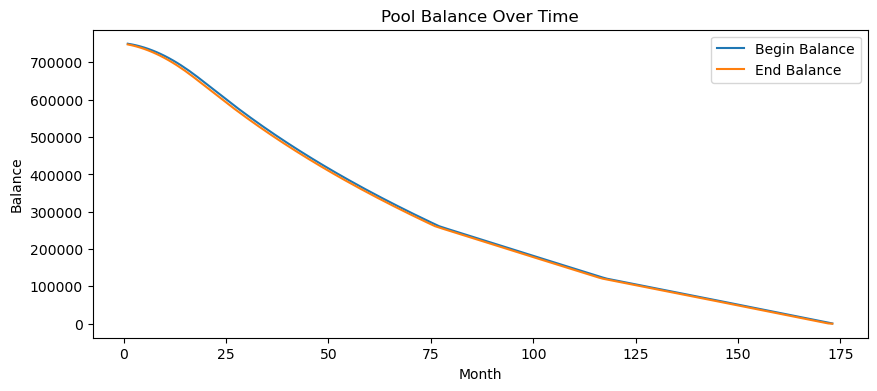

In [14]:
plt.figure(figsize=(10,4))
plt.plot(pool["month"], pool["begin_balance"], label="Begin Balance")
plt.plot(pool["month"], pool["end_balance"], label="End Balance")
plt.title("Pool Balance Over Time")
plt.xlabel("Month")
plt.ylabel("Balance")
plt.legend()
plt.show()

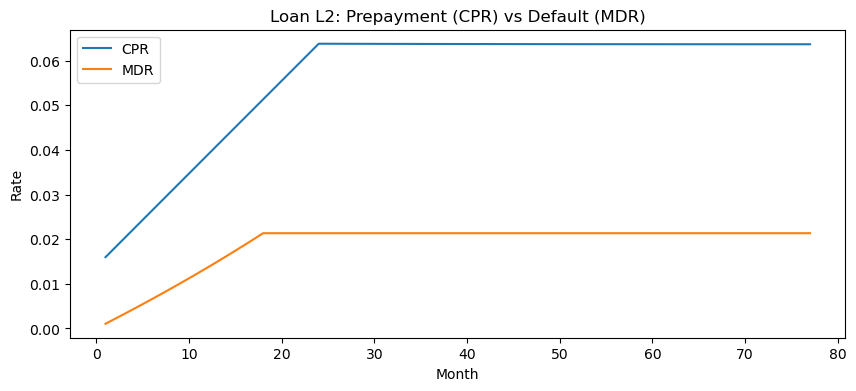

In [15]:
# Loan-level CPR/MDR plot (pick one loan)
loan_id = "L2"
tmp = cfs_all[cfs_all["loan_id"] == loan_id]

plt.figure(figsize=(10,4))
plt.plot(tmp["month"], tmp["cpr"], label="CPR")
plt.plot(tmp["month"], tmp["mdr"], label="MDR")
plt.title(f"Loan {loan_id}: Prepayment (CPR) vs Default (MDR)")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.legend()
plt.show()

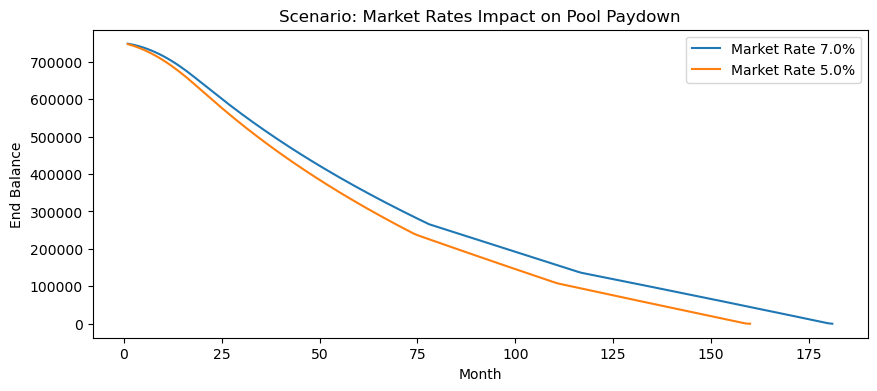

(6.6814611916365685, 5.729274022422903)

In [16]:
curve_high = flat_curve(0.070, 360)
curve_low  = flat_curve(0.050, 360)

def run_pool(loans, curve):
    cfs = pd.concat([simulate_loan_cashflows(l, curve, 360) for l in loans], ignore_index=True)
    pool = aggregate_pool(cfs)
    return pool

pool_high = run_pool(loans, curve_high)
pool_low  = run_pool(loans, curve_low)

plt.figure(figsize=(10,4))
plt.plot(pool_high["month"], pool_high["end_balance"], label="Market Rate 7.0%")
plt.plot(pool_low["month"], pool_low["end_balance"], label="Market Rate 5.0%")
plt.title("Scenario: Market Rates Impact on Pool Paydown")
plt.xlabel("Month")
plt.ylabel("End Balance")
plt.legend()
plt.show()

wal_high = wal_months(pool_high)/12
wal_low  = wal_months(pool_low)/12
wal_high, wal_low

## Key Results

### Pool Summary Statistics
For the example mortgage pool analysed in this notebook, the model produces:

- **Original Pool Balance:** 750,000  
- **Weighted Average Life (WAL):** ~6.33 years  
- **Present Value (discounted at 6.0%):** ~659,611  
- **Implied Price:** ~87.95% of par  

**Interpretation:**  
Although the underlying loans have long contractual maturities, prepayments significantly shorten the effective life of the pool. Discounting projected cashflows and incorporating expected losses results in a valuation below par.

---

### Pool Balance Dynamics
The pool balance declines smoothly over time, with the gap between beginning and ending balances in each month representing:
- Scheduled principal repayments
- Prepayments
- Defaults (net of recoveries)

The accelerated runoff relative to contractual maturity reflects realistic mortgage behaviour in the presence of refinancing incentives.

---

### Prepayment vs Credit Risk
Loan-level diagnostics show that:
- Prepayment rates (CPR) rise with seasoning and stabilise
- Default rates (MDR) remain materially lower than prepayment rates

**Key insight:**  
Mortgage cashflows in this setup are primarily driven by **interest-rate and prepayment risk**, rather than by credit losses.

---

### Interest-Rate Scenario Analysis
The notebook compares pool behaviour under different market rate assumptions:

- **Market rate 7.0%:** Slower prepayments → longer WAL (~6.68 years)  
- **Market rate 5.0%:** Faster prepayments → shorter WAL (~5.73 years)

**Interpretation:**  
Lower market rates increase refinancing incentives, accelerating principal return and shortening the pool’s life. This demonstrates the strong sensitivity of mortgage products to interest-rate environments.

---

## Overall Takeaways
- Mortgage pool risk is dominated by **prepayment timing**, not credit losses
- Prepayments materially reduce WAL relative to contractual maturity
- Pool valuation and risk metrics are highly sensitive to market interest rates
- The modelling framework produces economically intuitive and internally consistent results

---

## Conclusion
This notebook demonstrates a complete and interpretable mortgage risk-modelling workflow, combining loan-level cashflow projection, pool aggregation, behavioural diagnostics, and scenario analysis. The results highlight the central role of prepayment behaviour in mortgage valuation and risk management, providing a foundation for further extensions such as MSR valuation, structured product waterfalls, and Monte Carlo stress testing.
